# DBMS Workload Summarization using LSTM Encoder-Decoder & K-Means Clustering

**Project Overview:** This notebook implements an end-to-end pipeline for summarizing DBMS query workloads. We use a pre-trained Bidirectional LSTM Encoder-Decoder with Attention to encode SQL queries into dense vector representations, then apply K-Means clustering to group similar queries. The optimal number of clusters is determined using both the **Elbow Method** and **Silhouette Analysis**.

### Pipeline Steps
1. **Data Loading & Preprocessing** — Load ~100K SQL queries, tokenize and encode them
2. **Model Architecture** — Bidirectional LSTM Encoder-Decoder with Bahdanau Attention
3. **Query Encoding** — Generate dense vector representations using the pre-trained encoder
4. **Clustering Analysis** — K-Means with Elbow & Silhouette methods for optimal K
5. **Evaluation & Visualization** — Comprehensive metrics, plots, and cluster drill-down

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import re
import sqlparse
import warnings
import logging

from collections import Counter
from typing import List, Tuple, Optional, Dict
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from functools import partial
from sqlparse.tokens import Number, String
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128


## 2. Data Loading & Preprocessing

We load SQL queries from `sql_queries.txt` (separated by `#$@`), tokenize them using `sqlparse`, mask numeric/string literals, and convert tokens to integer IDs using a pre-built vocabulary.

In [4]:
# ── Load raw queries ──
DATA_FILE = "/kaggle/input/datasets/balasiva2006/work-load-summerization/dbms_projectt/generated_data/sql_queries.txt"

with open(DATA_FILE, "r", encoding="utf-8") as f:
    content = f.read()

raw_statements = content.split("#$@")
raw_statements = [q.replace("!#@", "").strip() for q in raw_statements if q.strip()]

print(f"Total SQL queries loaded: {len(raw_statements):,}")
print(f"\nSample queries:")
for i, q in enumerate(raw_statements[:3], 1):
    print(f"  [{i}] {q[:120]}{'...' if len(q)>120 else ''}")

Total SQL queries loaded: 106,579

Sample queries:
  [1] select * from Field where fieldId=0x08290cfd60860000
  [2] Select P.ra, P.dec, P.htmID, Q.objID,Q.photoz,Q.photozErr,Q.flag from PhotoObjAll P, Photoz2 Q where ((P.htmID >= 145044...
  [3] Select P.ra, P.dec, P.htmID, Q.objID,Q.photoz,Q.photozErr,Q.flag from PhotoObjAll P, Photoz2 Q where ((P.htmID >= 145044...


In [5]:
# ── SQL Tokenizer ──
class SQLTokenizer:
    def __init__(self, vocab_path="/kaggle/input/datasets/balasiva2006/work-load-summerization/dbms_projectt/generated_data/final_encoded_data.pt"):
        data = torch.load(vocab_path, weights_only=False)
        if 'token2id' in data:
            self.token2id = data['token2id']
            self.id2token = data['id2token']
        else:
            self.token2id = data
            self.id2token = {v: k for k, v in data.items()}
        self.unk_id = self.token2id.get("<UNK>", 2)
        self.sneaky_number_pattern = re.compile(
            r'^[-+]?(?:\d+\.\d*|\d*\.\d+|\d+)(?:[eE][-+]?\d+)?$'
        )

    @staticmethod
    def normalize_sql(sql):
        if not isinstance(sql, str):
            return ""
        sql = sql.lower().strip()
        return re.sub(r'\s+', ' ', sql)

    def tokenize_sql(self, sql):
        sql = self.normalize_sql(sql)
        if not sql:
            return []
        parsed = sqlparse.parse(sql)
        if not parsed:
            return []
        tokens = []
        for token in parsed[0].flatten():
            if token.is_whitespace:
                continue
            if token.ttype in Number:
                tokens.append('NUM_LITERAL')
            elif token.ttype in String:
                tokens.append('STR_LITERAL')
            elif token.value.startswith('0x') and len(token.value) > 2:
                tokens.append('HEX_LITERAL')
            else:
                tokens.append(token.value)
        return tokens

    def _fix_sneaky_numbers(self, tokens):
        fixed = []
        for token in tokens:
            if self.sneaky_number_pattern.fullmatch(token) or re.fullmatch(r'^[-+]?\d+$', token):
                fixed.append('NUM_LITERAL')
            else:
                fixed.append(token)
        return fixed

    def encode(self, sql):
        tokens = self.tokenize_sql(sql)
        tokens = self._fix_sneaky_numbers(tokens)
        return [self.token2id.get(tok, self.unk_id) for tok in tokens]

    def encode_batch(self, sql_list):
        rows = []
        for sql in sql_list:
            tokens = self.tokenize_sql(sql)
            tokens = self._fix_sneaky_numbers(tokens)
            token_ids = [self.token2id.get(tok, self.unk_id) for tok in tokens]
            rows.append({'sql': sql, 'tokens': tokens, 'token_ids': token_ids})
        df = pd.DataFrame(rows)
        return df, self.token2id, self.id2token

# Tokenize all queries
tokenizer = SQLTokenizer("/kaggle/input/datasets/balasiva2006/work-load-summerization/dbms_projectt/generated_data/final_encoded_data.pt")
df_train, token2id, id2token = tokenizer.encode_batch(raw_statements)

pad_idx = token2id.get("<PAD>", 0)
vocab_size = len(token2id)

print(f"Vocabulary size: {vocab_size:,}")
print(f"PAD index: {pad_idx}")
print(f"DataFrame shape: {df_train.shape}")
df_train.head()

Vocabulary size: 7,184
PAD index: 0
DataFrame shape: (106579, 3)


,sql,tokens,token_ids
0,select * from Field where fieldId=0x08290cfd60...,"[select, *, from, field, where, fieldid, =, NU...","[5362, 10, 2293, 2127, 7071, 2128, 34, 38]"
1,"Select P.ra, P.dec, P.htmID, Q.objID,Q.photoz,...","[select, p, ., ra, ,, p, ., dec, ,, p, ., htmi...","[5362, 3904, 16, 4583, 12, 3904, 16, 1783, 12,..."
2,"Select P.ra, P.dec, P.htmID, Q.objID,Q.photoz,...","[select, p, ., ra, ,, p, ., dec, ,, p, ., htmi...","[5362, 3904, 16, 4583, 12, 3904, 16, 1783, 12,..."
3,"select name, type from DBObjects where type='V...","[select, name, ,, type, from, dbobjects, where...","[5362, 3507, 12, 6650, 2293, 1777, 7071, 6650,..."
4,"select name, type from DBObjects where type='V...","[select, name, ,, type, from, dbobjects, where...","[5362, 3507, 12, 6650, 2293, 1777, 7071, 6650,..."


### 2.1 Data Statistics

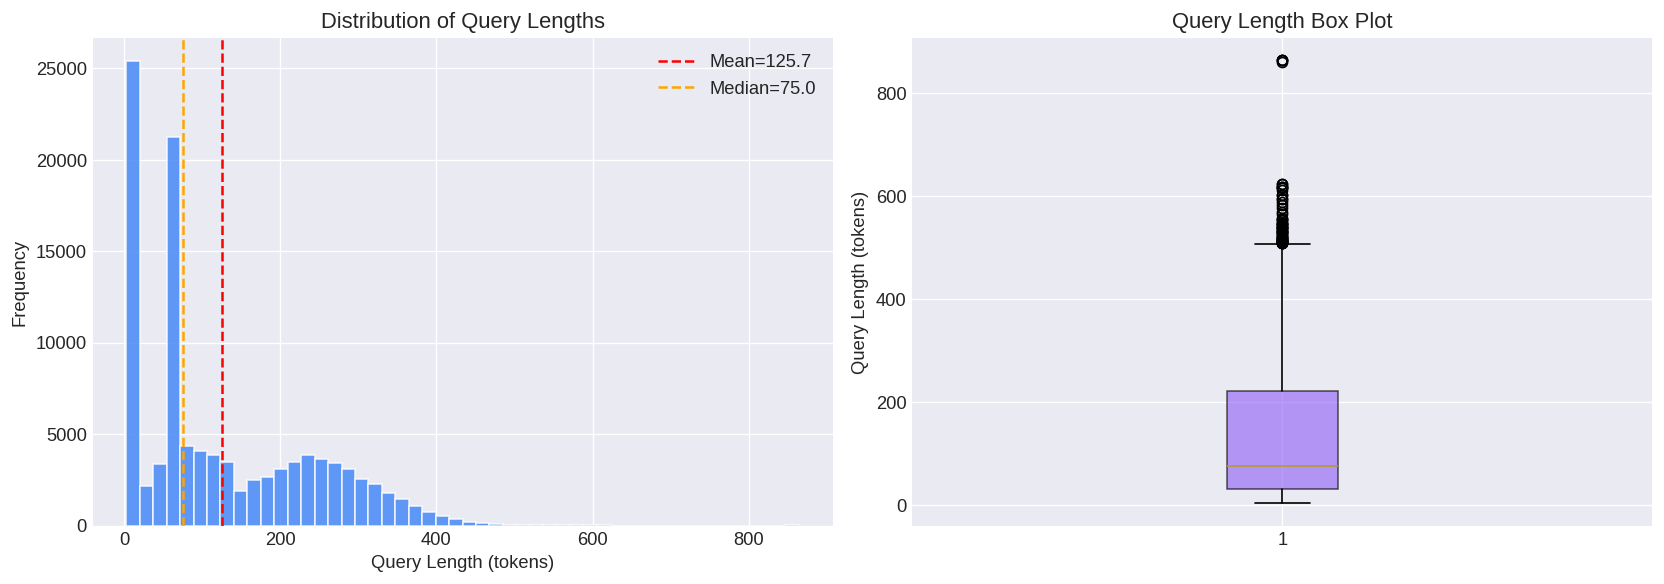

Query Length Statistics:
  Min: 3, Max: 864
  Mean: 125.7, Median: 75.0
  Std: 114.4
  Total queries: 106,579


In [6]:
# Query length distribution
query_lengths = df_train['token_ids'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of query lengths
axes[0].hist(query_lengths, bins=50, color='#3b82f6', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('Query Length (tokens)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Query Lengths')
axes[0].axvline(query_lengths.mean(), color='red', linestyle='--', label=f'Mean={query_lengths.mean():.1f}')
axes[0].axvline(query_lengths.median(), color='orange', linestyle='--', label=f'Median={query_lengths.median():.1f}')
axes[0].legend()

# Box plot
axes[1].boxplot(query_lengths, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#8b5cf6', alpha=0.6))
axes[1].set_ylabel('Query Length (tokens)')
axes[1].set_title('Query Length Box Plot')

plt.tight_layout()
plt.show()

print(f"Query Length Statistics:")
print(f"  Min: {query_lengths.min()}, Max: {query_lengths.max()}")
print(f"  Mean: {query_lengths.mean():.1f}, Median: {query_lengths.median():.1f}")
print(f"  Std: {query_lengths.std():.1f}")
print(f"  Total queries: {len(query_lengths):,}")

## 3. LSTM Encoder-Decoder Model Architecture

Our model uses:
- **Embedding Layer** with positional encoding
- **Bidirectional LSTM Encoder** (2 layers, hidden_dim=64)
- **Bahdanau Attention** mechanism for context-aware encoding
- **LSTM Decoder** for reconstruction (used during training)

For clustering, we only use the **encoder** to generate 128-dimensional query vectors.

In [9]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class ATTENTION(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, hidden, encoder_outputs):
        h = hidden[0]
        forward_h = h[-2, :, :]
        backward_h = h[-1, :, :]
        last_hidden = torch.cat([forward_h, backward_h], dim=1).unsqueeze(1)
        score = self.V(torch.tanh(self.W1(encoder_outputs) + self.W2(last_hidden)))
        attention_weights = torch.softmax(score, dim=1)
        context = torch.sum(attention_weights * encoder_outputs, dim=1)
        return context


class LSTMENCODERDECODER(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=256, num_layers=1,
                 dropout=0.3, pad_idx=0, use_attention=True, use_vae=False):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.pad_idx = pad_idx
        self.use_attention = use_attention
        self.use_vae = use_vae

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(embed_dim)
        self.encoder = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                               batch_first=True, bidirectional=True,
                               dropout=dropout if num_layers > 1 else 0)
        if use_attention:
            self.attention = ATTENTION(hidden_dim * 2)
        if use_vae:
            self.fc_mu = nn.Linear(hidden_dim * 2, hidden_dim * 2)
            self.fc_logvar = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.bridge = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.decoder = nn.LSTM(embed_dim, hidden_dim * 2, num_layers=num_layers,
                               batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc_out = nn.Linear(hidden_dim * 2, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)

    def encode(self, x, lengths=None):
        embedded = self.dropout(self.embedding(x))
        embedded = self.pos_encoding(embedded)
        if lengths is not None:
            packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
            output, hidden = self.encoder(packed)
            output, _ = pad_packed_sequence(output, batch_first=True)
        else:
            output, hidden = self.encoder(embedded)
        return output, hidden

    def get_query_vector(self, x, lengths=None):
        with torch.no_grad():
            encoder_outputs, encoder_hidden = self.encode(x, lengths)
            if self.use_attention:
                query_vec = self.attention(encoder_hidden, encoder_outputs)
            else:
                fwd = encoder_hidden[0][-2, :, :]
                bwd = encoder_hidden[0][-1, :, :]
                query_vec = torch.cat([fwd, bwd], dim=1)
            if self.use_vae:
                query_vec = self.fc_mu(query_vec)
            return query_vec

# Model config
EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT = 64, 64, 2, 0.3

model = LSTMENCODERDECODER(
    vocab_size=vocab_size, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS, dropout=DROPOUT, pad_idx=pad_idx,
    use_attention=True, use_vae=False
).to(DEVICE)

# Load pre-trained weights
checkpoint = torch.load("/kaggle/input/datasets/balasiva2006/work-load-summerization/dbms_projectt/trained_models/lstm_weigths.pth", map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model_state_dict"] if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model loaded successfully!")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable:,}")
print(f"  Encoder output dim: {HIDDEN_DIM * 2} (bidirectional)")
print(f"  Attention: Enabled (Bahdanau)")

Model loaded successfully!
  Total parameters: 1,833,745
  Trainable parameters: 1,833,745
  Encoder output dim: 128 (bidirectional)
  Attention: Enabled (Bahdanau)


## 4. Query Encoding

We pass all queries through the LSTM encoder to obtain dense 128-dimensional vector representations.

In [10]:
class SQLDataset(Dataset):
    def __init__(self, df):
        self.data = df["token_ids"].tolist()
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        ids = self.data[idx]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(len(ids), dtype=torch.long)

def collate_fn(batch, pad_idx):
    seqs, lengths = zip(*batch)
    max_len = max(s.size(0) for s in seqs)
    padded = torch.full((len(seqs), max_len), pad_idx, dtype=torch.long)
    for i, seq in enumerate(seqs):
        padded[i, :seq.size(0)] = seq
    return padded, torch.stack(list(lengths))

BATCH_SIZE = 64
loader = DataLoader(SQLDataset(df_train), batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=0, collate_fn=partial(collate_fn, pad_idx=pad_idx))

print(f"Encoding {len(df_train):,} queries...")
all_vectors = []
with torch.no_grad():
    for batch_ids, batch_lengths in loader:
        vecs = model.get_query_vector(batch_ids.to(DEVICE), batch_lengths.to(DEVICE))
        all_vectors.append(vecs.cpu().numpy())

query_vectors = np.vstack(all_vectors)
print(f"Encoding complete!")
print(f"  Shape: {query_vectors.shape}  (queries × embedding_dim)")
print(f"  Vector norm range: [{np.linalg.norm(query_vectors, axis=1).min():.3f}, {np.linalg.norm(query_vectors, axis=1).max():.3f}]")

Encoding 106,579 queries...
Encoding complete!
  Shape: (106579, 128)  (queries × embedding_dim)
  Vector norm range: [3.858, 8.481]


### 4.1 PCA Analysis of Query Embeddings

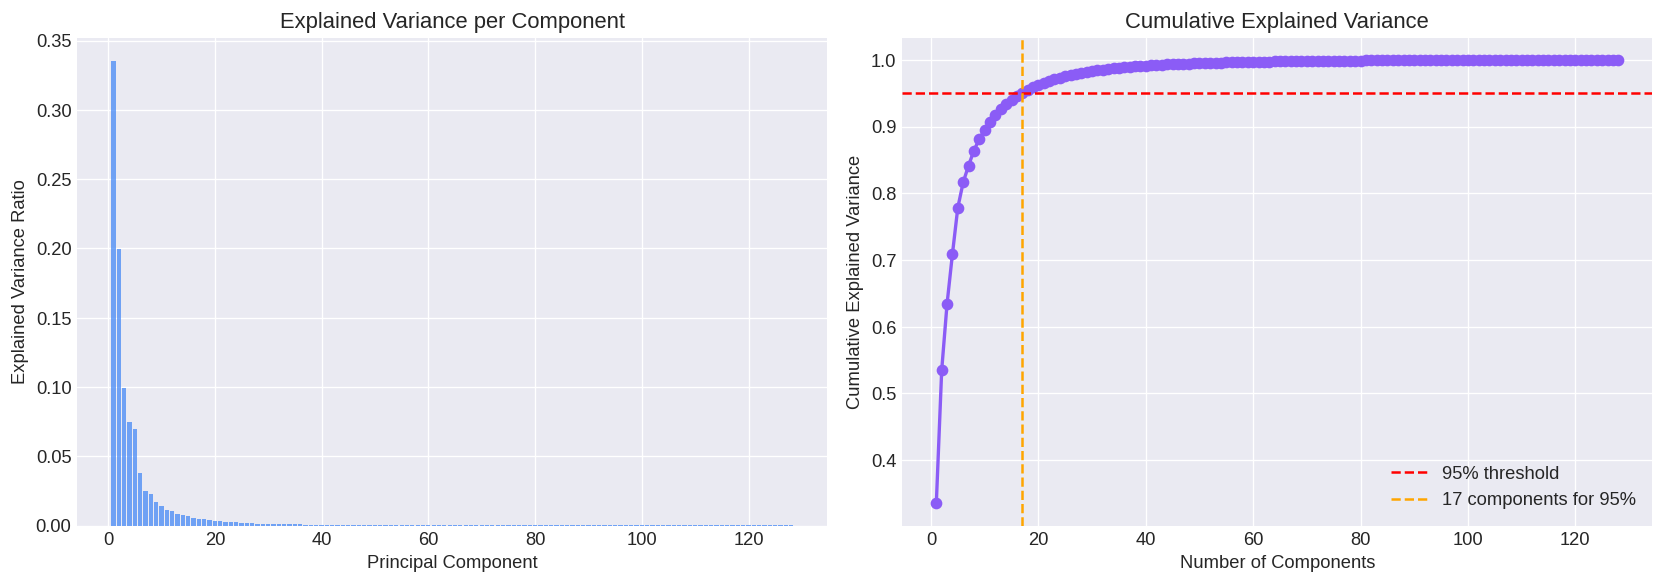

Components for 95% variance: 17
Top 5 component variance: [0.3354 0.1995 0.0995 0.0746 0.0694]


In [11]:
pca_full = PCA(random_state=42)
pca_full.fit(query_vectors)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='#3b82f6', alpha=0.7)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Explained Variance per Component')

axes[1].plot(range(1, len(cumvar)+1), cumvar, 'o-', color='#8b5cf6', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
n95 = np.argmax(cumvar >= 0.95) + 1
axes[1].axvline(x=n95, color='orange', linestyle='--', label=f'{n95} components for 95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Components for 95% variance: {n95}")
print(f"Top 5 component variance: {pca_full.explained_variance_ratio_[:5].round(4)}")

## 5. Clustering Analysis — Determining Optimal K

We evaluate K from 2 to 50 using:
- **Elbow Method** (minimizing inertia / within-cluster sum of squares)
- **Silhouette Analysis** (maximizing cluster cohesion & separation)
- **Calinski-Harabasz Index** (higher = better-defined clusters)
- **Davies-Bouldin Index** (lower = better separation)

In [14]:
raw_queries = df_train["sql"].tolist()

# Range of K values
min_k, max_k = 15, min(50, max(len(raw_queries) // 10, 3))
k_values = list(range(min_k, max_k + 1,3))

print(f"Testing K values: {min_k} to {max_k}")
print(f"Number of queries: {len(raw_queries):,}\n")

inertias = []
sil_scores = []
ch_scores = []
db_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(query_vectors)
    inertias.append(float(kmeans.inertia_))
    sil = silhouette_score(query_vectors, labels)
    sil_scores.append(float(sil))
    ch_scores.append(float(calinski_harabasz_score(query_vectors, labels)))
    db_scores.append(float(davies_bouldin_score(query_vectors, labels)))
    if k % 5 == 0 or k == min_k:
        print(f"  K={k:3d}  |  Inertia={kmeans.inertia_:12.1f}  |  Silhouette={sil:.4f}  |  CH={ch_scores[-1]:.1f}  |  DB={db_scores[-1]:.4f}")

print(f"\nDone! Evaluated {len(k_values)} values of K.")

Testing K values: 15 to 50
Number of queries: 106,579

  K= 15  |  Inertia=    599689.9  |  Silhouette=0.5118  |  CH=37838.4  |  DB=1.0977
  K= 30  |  Inertia=    315371.0  |  Silhouette=0.5638  |  CH=38042.8  |  DB=0.9785
  K= 45  |  Inertia=    199854.4  |  Silhouette=0.6022  |  CH=40960.5  |  DB=0.8820

Done! Evaluated 12 values of K.


### 5.1 Elbow Method Analysis

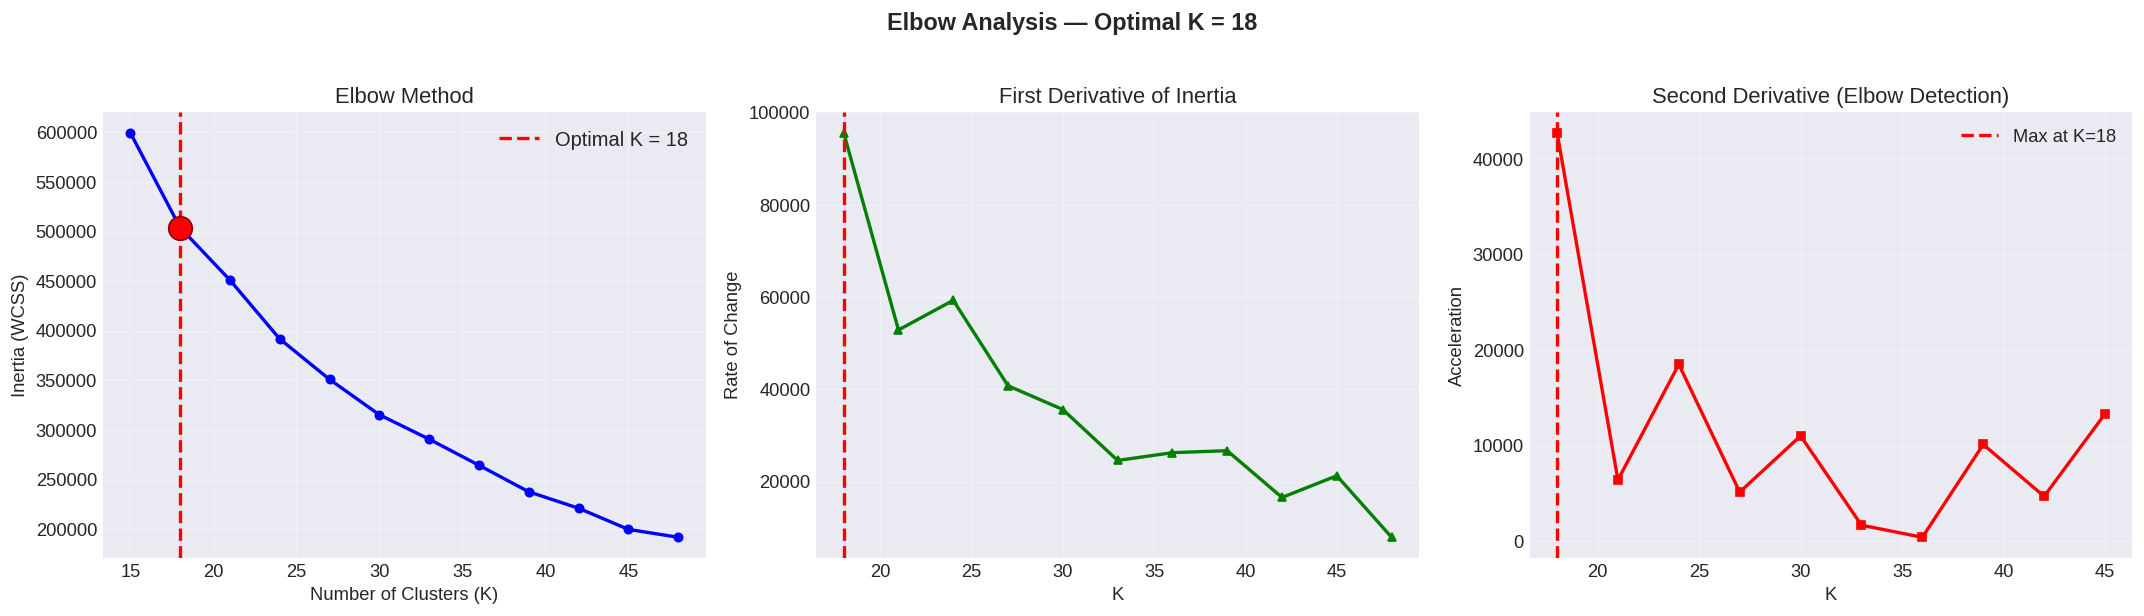


 Elbow Method → Optimal K = 18
   Inertia at K=18: 504,027.9


In [15]:
# Find elbow point using second derivative
rates = [abs(inertias[i] - inertias[i-1]) for i in range(1, len(inertias))]
second_deriv = [abs(rates[i] - rates[i-1]) for i in range(1, len(rates))]
elbow_idx = int(np.argmax(second_deriv)) + 1
elbow_k = k_values[elbow_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Elbow curve
axes[0].plot(k_values, inertias, 'bo-', linewidth=2, markersize=5)
axes[0].axvline(x=elbow_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K = {elbow_k}')
axes[0].scatter([elbow_k], [inertias[elbow_idx]], s=200, c='red', zorder=5, edgecolors='darkred')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# First derivative
axes[1].plot(k_values[1:], rates, 'g^-', linewidth=2, markersize=5)
axes[1].axvline(x=elbow_k, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Rate of Change')
axes[1].set_title('First Derivative of Inertia')
axes[1].grid(True, alpha=0.3)

# Second derivative
axes[2].plot(k_values[1:-1], second_deriv, 'rs-', linewidth=2, markersize=5)
max_sd_k = k_values[int(np.argmax(second_deriv)) + 1]
axes[2].axvline(x=max_sd_k, color='red', linestyle='--', linewidth=2, label=f'Max at K={max_sd_k}')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Acceleration')
axes[2].set_title('Second Derivative (Elbow Detection)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Elbow Analysis — Optimal K = {elbow_k}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n Elbow Method → Optimal K = {elbow_k}")
print(f"   Inertia at K={elbow_k}: {inertias[elbow_idx]:,.1f}")

## 6. Final Clustering with Optimal K (Elbow Method)

In [ ]:
optimal_k = elbow_k
print(f"Using optimal K = {optimal_k} (from Elbow method)\n")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(query_vectors)
centroids = kmeans_final.cluster_centers_

summary_queries = []
for cid in range(optimal_k):
    mask = cluster_labels == cid
    c_vecs = query_vectors[mask]
    c_idx = np.where(mask)[0]
    dists = np.linalg.norm(c_vecs - centroids[cid], axis=1)
    nearest = c_idx[int(np.argmin(dists))]
    summary_queries.append(raw_queries[nearest])

# Statistics
cluster_sizes = [int(np.sum(cluster_labels == i)) for i in range(optimal_k)]
compression = (1 - len(summary_queries) / len(raw_queries)) * 100

print(f"{'='*60}")
print(f"  CLUSTERING RESULTS")
print(f"{'='*60}")
print(f"  Original workload:   {len(raw_queries):>10,} queries")
print(f"  Summary workload:    {len(summary_queries):>10,} queries")
print(f"  Compression ratio:   {compression:>10.2f}%")
print(f"  Number of clusters:  {optimal_k:>10}")
print(f"  Avg cluster size:    {np.mean(cluster_sizes):>10.1f}")
print(f"  Std cluster size:    {np.std(cluster_sizes):>10.1f}")
print(f"  Min cluster size:    {min(cluster_sizes):>10}")
print(f"  Max cluster size:    {max(cluster_sizes):>10}")
print(f"{'='*60}")

Using optimal K = 18 (from Elbow method)

  CLUSTERING RESULTS
  Original workload:      106,579 queries
  Summary workload:            18 queries
  Compression ratio:        99.98%
  Number of clusters:          18
  Avg cluster size:        5921.1
  Std cluster size:        4075.3
  Min cluster size:          1750
  Max cluster size:         17021


### 6.1 Cluster Size Distribution

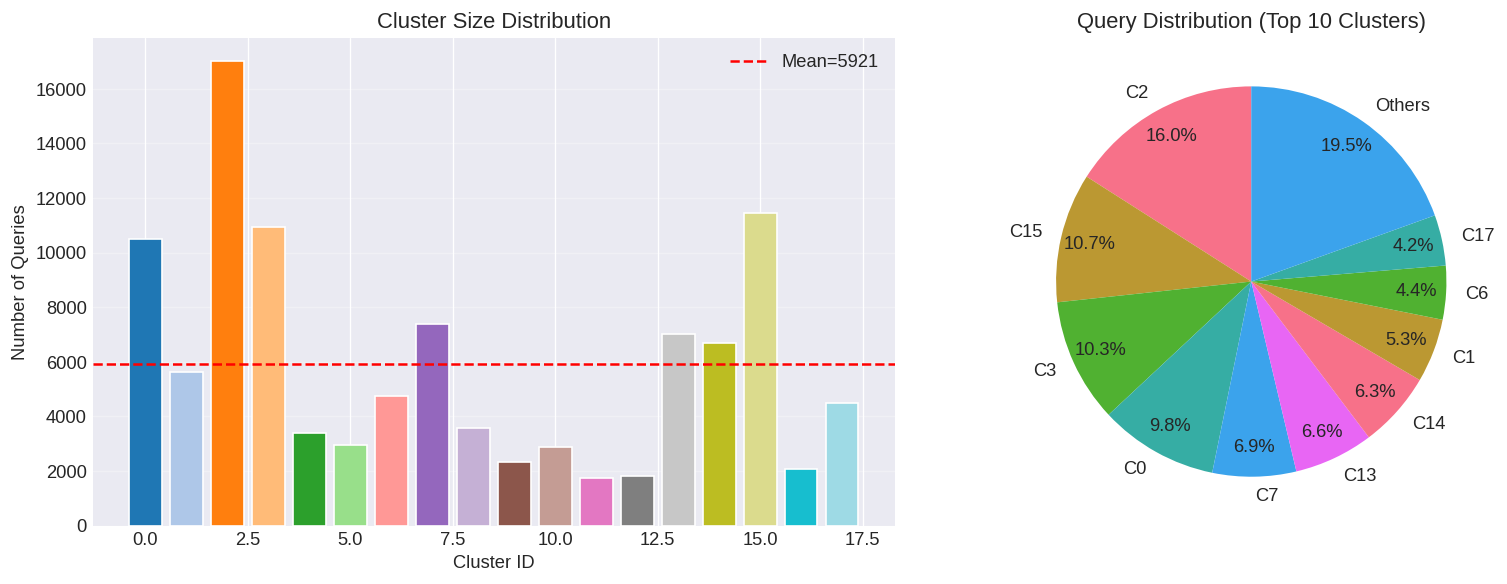

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_bar = plt.cm.tab20(np.linspace(0, 1, optimal_k))
axes[0].bar(range(optimal_k), cluster_sizes, color=colors_bar, edgecolor='white')
axes[0].set_xlabel('Cluster ID')
axes[0].set_ylabel('Number of Queries')
axes[0].set_title('Cluster Size Distribution')
axes[0].axhline(y=np.mean(cluster_sizes), color='red', linestyle='--', label=f'Mean={np.mean(cluster_sizes):.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Pie chart (top clusters)
sorted_idx = np.argsort(cluster_sizes)[::-1]
top_n = min(10, optimal_k)
top_sizes = [cluster_sizes[i] for i in sorted_idx[:top_n]]
top_labels = [f'C{sorted_idx[i]}' for i in range(top_n)]
if optimal_k > top_n:
    other = sum(cluster_sizes[i] for i in sorted_idx[top_n:])
    top_sizes.append(other)
    top_labels.append('Others')
axes[1].pie(top_sizes, labels=top_labels, autopct='%1.1f%%', startangle=90, pctdistance=0.85)
axes[1].set_title(f'Query Distribution (Top {top_n} Clusters)')

plt.tight_layout()
plt.show()

### 6.2 Cluster Visualization (PCA Projection)

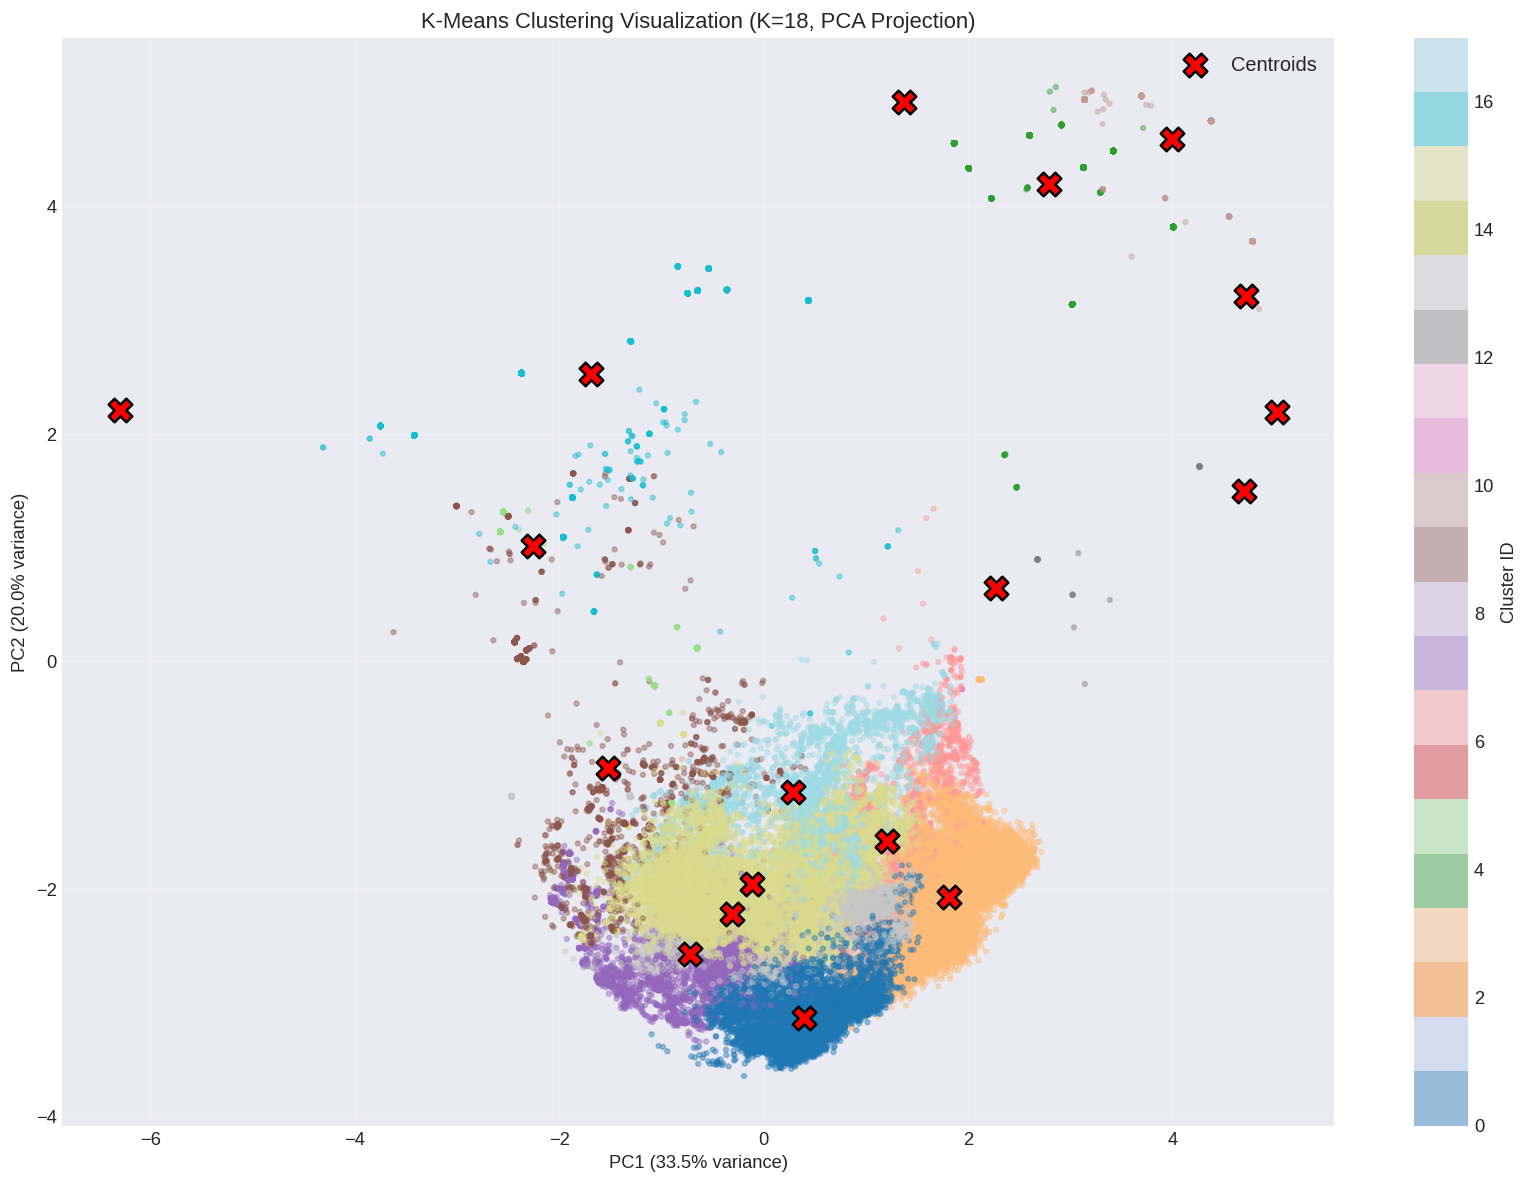

PCA explains 53.5% of total variance in 2D


In [20]:
pca_2d = PCA(n_components=2, random_state=42)
vectors_2d = pca_2d.fit_transform(query_vectors)
centroids_2d = pca_2d.transform(centroids)

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c=cluster_labels,
                     cmap='tab20', alpha=0.4, s=8)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='red', marker='X',
           s=200, edgecolors='black', linewidths=1.5, label='Centroids', zorder=5)
plt.colorbar(scatter, label='Cluster ID', ax=ax)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title(f'K-Means Clustering Visualization (K={optimal_k}, PCA Projection)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"PCA explains {sum(pca_2d.explained_variance_ratio_)*100:.1f}% of total variance in 2D")

## 7. Cluster Centers & Sample Queries

Each cluster center is the query closest to the centroid in embedding space.

In [22]:
print(f"{'='*80}")
print(f"  CLUSTER CENTER QUERIES (K={optimal_k})")
print(f"{'='*80}")

for cid in range(optimal_k):
    mask = cluster_labels == cid
    c_idx = np.where(mask)[0]
    c_vecs = query_vectors[mask]
    dists = np.linalg.norm(c_vecs - centroids[cid], axis=1)
    sorted_order = np.argsort(dists)

    center_query = raw_queries[c_idx[sorted_order[0]]]

    print(f"\n{'─'*80}")
    print(f"  Cluster {cid} | {len(c_idx):,} queries")
    print(f"  Center: {center_query[:150]}{'...' if len(center_query)>150 else ''}")
    print(f"  Sample queries from this cluster:")
    for j in range(min(5, len(sorted_order))):
        idx = c_idx[sorted_order[j]]
        q = raw_queries[idx]
        print(f"    [{j+1}] {q[:120]}{'...' if len(q)>120 else ''}")

print(f"\n{'='*80}")

  CLUSTER CENTER QUERIES (K=18)

────────────────────────────────────────────────────────────────────────────────
  Cluster 0 | 10,485 queries
  Center: WITH ranked_movies AS (     SELECT          t.title AS movie_title,          t.production_year,          a.name AS actor_name,          ROW_NUMBER() O...
  Sample queries from this cluster:
    [1] WITH ranked_movies AS (     SELECT          t.title AS movie_title,          t.production_year,          a.name AS actor...
    [2] WITH ranked_movies AS (     SELECT          a.title,         a.production_year,         c.name AS company_name,         ...
    [3] WITH ranked_movies AS (     SELECT          t.id AS movie_id,         t.title,         t.production_year,         ROW_NU...
    [4] WITH ranked_titles AS (     SELECT          a.title AS movie_title,         t.production_year,         r.role,         a...
    [5] WITH actor_movie_details AS (     SELECT          a.id AS actor_id,         a.name AS actor_name,         t.title AS mov.

## 8. Final Summary

### Results Overview

In [23]:
final_sil = silhouette_score(query_vectors, cluster_labels)
final_ch = calinski_harabasz_score(query_vectors, cluster_labels)
final_db = davies_bouldin_score(query_vectors, cluster_labels)

print(f"╔{'═'*58}╗")
print(f"║{'DBMS WORKLOAD SUMMARIZATION — FINAL RESULTS':^58}║")
print(f"╠{'═'*58}╣")
print(f"║  Dataset size:           {len(raw_queries):>10,} queries{' '*13}║")
print(f"║  Embedding dimension:    {query_vectors.shape[1]:>10}{' '*18}║")
print(f"║  Optimal K (Elbow):      {elbow_k:>10}{' '*18}║")
print(f"║  Best K (Silhouette):    {sil_k:>10}{' '*18}║")
print(f"║  Summary queries:        {optimal_k:>10}{' '*18}║")
print(f"║  Compression ratio:      {compression:>10.2f}%{' '*17}║")
print(f"╠{'═'*58}╣")
print(f"║  {'EVALUATION METRICS':^56}║")
print(f"╠{'═'*58}╣")
print(f"║  Silhouette Score:       {final_sil:>10.4f} (higher=better){' '*6}║")
print(f"║  Calinski-Harabasz:      {final_ch:>10.1f} (higher=better){' '*6}║")
print(f"║  Davies-Bouldin:         {final_db:>10.4f} (lower=better){' '*7}║")
print(f"║  Avg Cluster Size:       {np.mean(cluster_sizes):>10.1f}{' '*18}║")
print(f"║  Std Cluster Size:       {np.std(cluster_sizes):>10.1f}{' '*18}║")
print(f"╚{'═'*58}╝")

╔══════════════════════════════════════════════════════════╗
║       DBMS WORKLOAD SUMMARIZATION — FINAL RESULTS        ║
╠══════════════════════════════════════════════════════════╣
║  Dataset size:              106,579 queries             ║
║  Embedding dimension:           128                  ║
║  Optimal K (Elbow):              18                  ║
║  Best K (Silhouette):            45                  ║
║  Summary queries:                18                  ║
║  Compression ratio:           99.98%                 ║
╠══════════════════════════════════════════════════════════╣
║                     EVALUATION METRICS                   ║
╠══════════════════════════════════════════════════════════╣
║  Silhouette Score:           0.5334 (higher=better)      ║
║  Calinski-Harabasz:         38264.9 (higher=better)      ║
║  Davies-Bouldin:             1.0812 (lower=better)       ║
║  Avg Cluster Size:           5921.1                  ║
║  Std Cluster Size:           4075.3            